# Fashion Dataset Quality Comparison

This notebook compares the original Fashion Product Images catalogue with the teacher-provided assignment split. It answers a narrow question: **which source is better for labels, image quality, and valid assignment use?**

The original catalogue contains labels for the 5,829 official test IDs. Those rows are analysed only in aggregate inside a **quarantined audit**. They must never be used for training, tuning, feature selection, or model comparison.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = Path("/localhome/local-lintran/MLA2")
sys.path.insert(0, str(ROOT / "src"))

from fashion.dataset_comparison import load_comparison_summary, run_dataset_comparison

OUTPUT_DIR = ROOT / "results/figures/dataset-comparison"
SUMMARY_PATH = OUTPUT_DIR / "comparison-summary.json"
FORCE_RECOMPUTE = os.environ.get("MLA2_RECOMPUTE_COMPARISON") == "1"
print(f"Repository: {ROOT}")
print(f"Force a fresh full scan: {FORCE_RECOMPUTE}")

Repository: /localhome/local-lintran/MLA2
Force a fresh full scan: False


## 1. Fresh audit or verified cached result

The full audit hashes roughly 14 GiB of images and checks 44,446 JSON files. Set `MLA2_RECOMPUTE_COMPARISON=1` before execution to force that scan. Otherwise this notebook loads the machine-readable output from the latest full scan.

In [2]:
if FORCE_RECOMPUTE or not SUMMARY_PATH.is_file():
    summary = run_dataset_comparison(OUTPUT_DIR, verbose=True)
else:
    summary = load_comparison_summary(SUMMARY_PATH)

pop = summary["populations"]
ids = summary["id_reconciliation"]
assert pop["original_metadata_rows"] == pop["teacher_train_metadata_rows"] + pop["teacher_test_rows"]
assert ids["original_equals_teacher_union"] is True
assert ids["teacher_train_test_overlap"] == 0
assert sum(ids["shared_label_mismatch_counts"].values()) == 0
print("Summary generated:", summary["generated_at_utc"])
print("All population and shared-label assertions passed.")

Summary generated: 2026-08-17T13:07:45.942576+00:00
All population and shared-label assertions passed.


## 2. Coverage and provenance

A label row is useful for image modelling only when its image exists. After restoring the teacher package, `train-old` contains all 38,612 available training JPGs. Five metadata rows still lack images in both the teacher package and the original source, so they are source-level orphans rather than transfer failures.

,source,metadata_rows,jpg_files
0,Original catalogue,44446,44441
1,Teacher train (current disk),38617,38612
2,Teacher test,5829,5829


,value
metadata_rows,38617
present_images,38612
missing_images,5
recoverable_from_original,0
unrecoverable_known_orphans,"[12347, 39401, 39403, 39410, 39425]"
first_missing_ids,"[12347, 39401, 39403, 39410, 39425]"
largest_present_id,51999


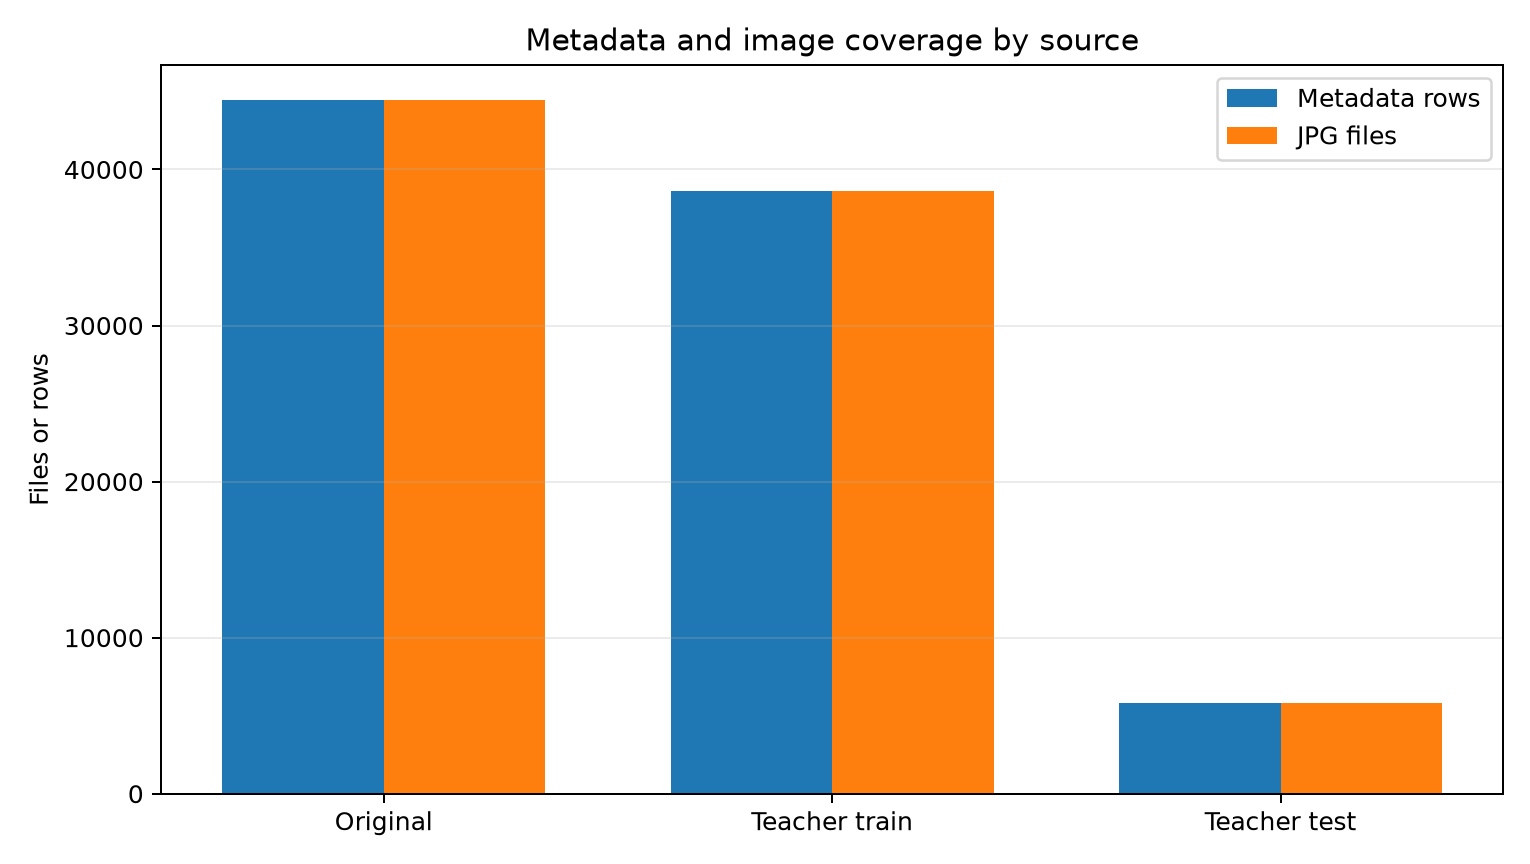

In [3]:
coverage = pd.DataFrame([
    {"source": "Original catalogue", "metadata_rows": pop["original_metadata_rows"], "jpg_files": pop["original_image_files"]},
    {"source": "Teacher train (current disk)", "metadata_rows": pop["teacher_train_metadata_rows"], "jpg_files": pop["teacher_train_image_files"]},
    {"source": "Teacher test", "metadata_rows": pop["teacher_test_rows"], "jpg_files": pop["teacher_test_image_files"]},
])
display(coverage)
display(pd.Series(summary["teacher_train_image_loss"], name="value").to_frame())
display(Image(filename=str(OUTPUT_DIR / "population-coverage.png")))

## 3. Label quality and split shift

The shared teacher-train and original rows are byte-for-byte equivalent after safe CSV parsing, so the original CSV is not a second independent labelling effort. Its extra value is the JSON cross-check and full catalogue context.

The split is ordered by product ID: teacher train ends at ID 51,999 and teacher test starts at 52,003. The quarantined test labels reveal strong distribution shift across this catalogue/time boundary. This is diagnostic evidence only. It must not be used to tune a model.

,target,train_classes,test_classes,total_variation,unseen_test_labels,unseen_test_rows
0,articleType,125,105,0.495994,18,234
2,gender,5,5,0.400521,0,0
1,season,5,5,0.206786,0,0
3,usage,10,8,0.137410,0,0


,label,test_rows
0,Face Moisturisers,61
1,Face Wash and Cleanser,28
2,Sunscreen,25
3,Bath Robe,20
4,Hair Colour,19
5,Lip Care,16
6,Mascara,13
7,Mask and Peel,12
8,Body Lotion,6
9,Eye Cream,6


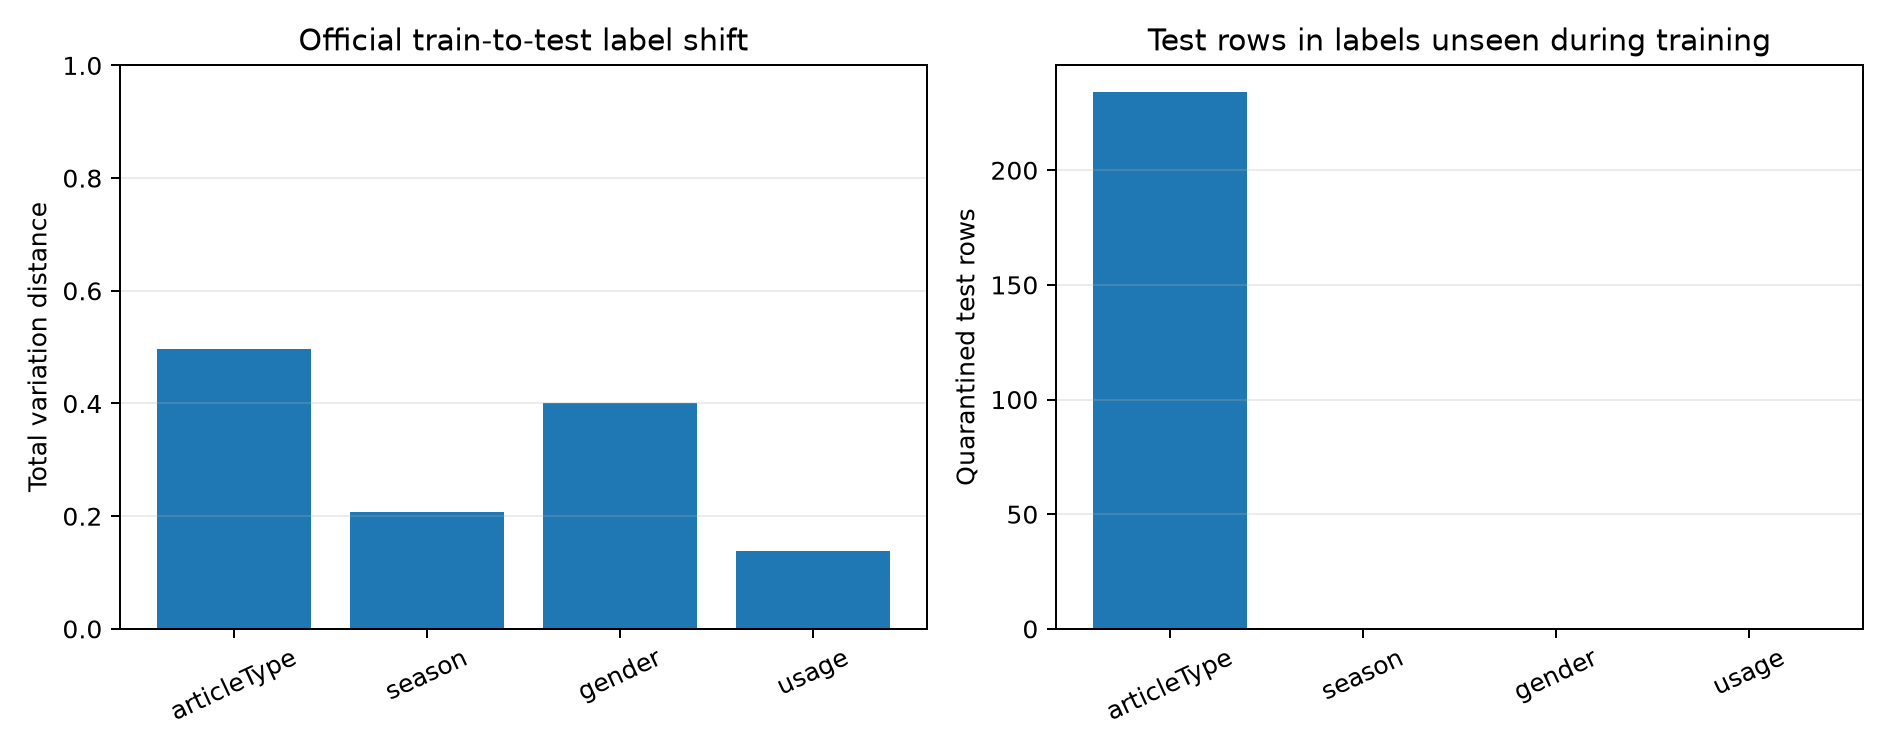

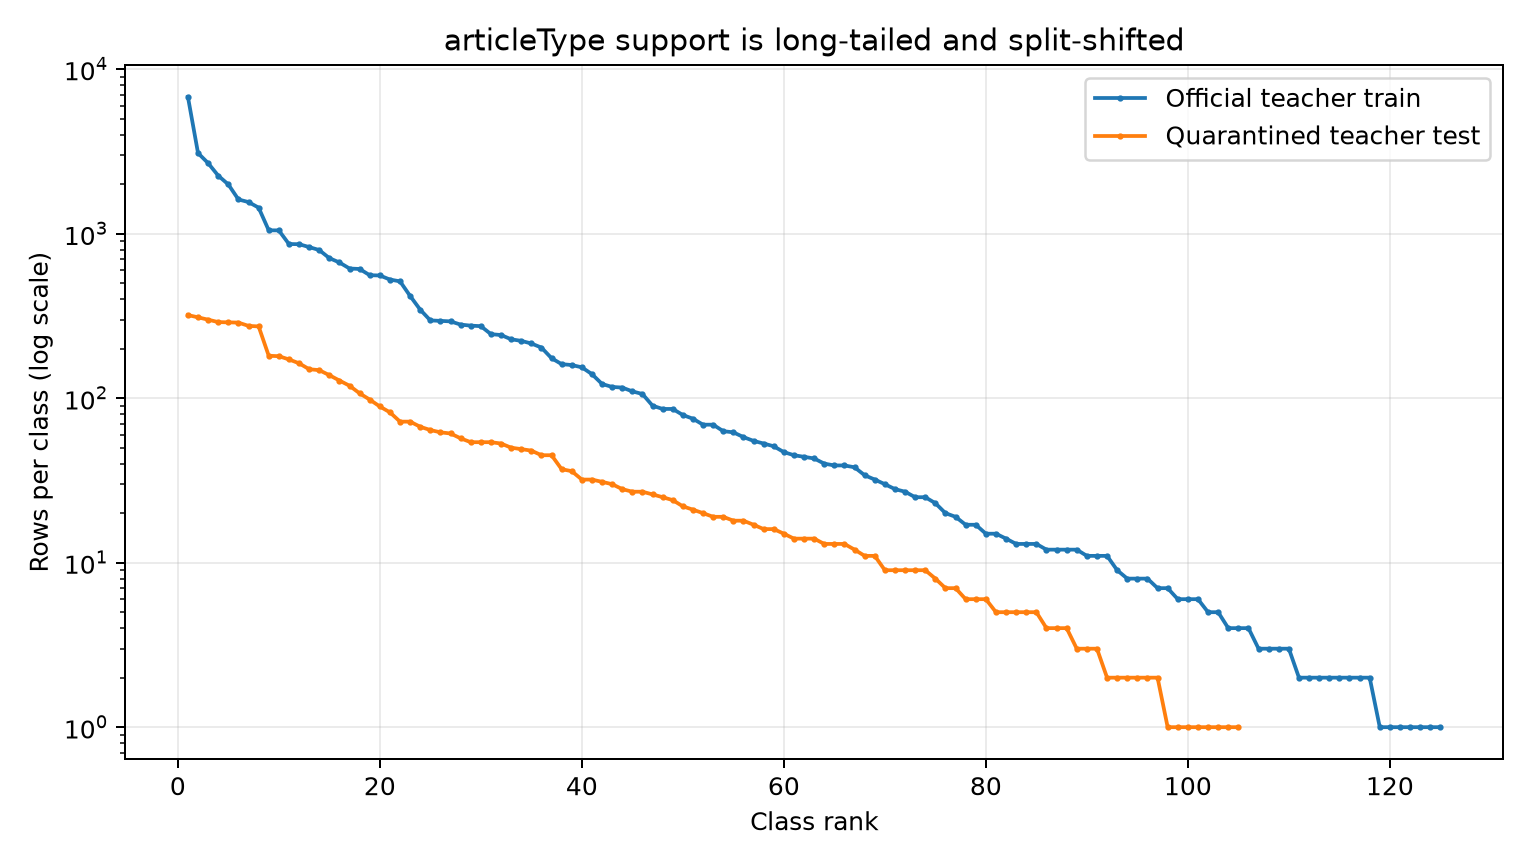

In [4]:
split_rows = []
for target, audit in summary["labels"]["split_comparison"].items():
    split_rows.append({
        "target": target,
        "train_classes": audit["train_classes"],
        "test_classes": audit["test_classes"],
        "total_variation": audit["total_variation"],
        "unseen_test_labels": len(audit["unseen_test_labels"]),
        "unseen_test_rows": audit["unseen_test_rows"],
    })
display(pd.DataFrame(split_rows).sort_values("total_variation", ascending=False))
display(pd.DataFrame(summary["labels"]["split_comparison"]["articleType"]["unseen_test_labels"]))
display(Image(filename=str(OUTPUT_DIR / "label-shift.png")))
display(Image(filename=str(OUTPUT_DIR / "article-type-long-tail.png")))

## 4. Weird and suspicious labels

Suspicion is not proof. Candidates are prioritised using strong signals: disagreement with the original JSON, identical images carrying different targets, explicit gender words contradicting the CSV, hierarchy conflicts, and very rare target combinations. Visual review is still required before changing a label.

,check,count
0,CSV ↔ JSON label mismatches,0
1,Exact-image groups with target conflicts,22
2,Name ↔ gender review candidates,392
3,articleType hierarchy conflicts,20
4,articleType singletons,7
5,articleType classes under 10 rows,33


,id,gender,masterCategory,subCategory,articleType,season,usage,productDisplayName
0,38223,Women,Accessories,Cufflinks,Ties and Cufflinks,Summer,Casual,Polaroid Women Sunglasses
1,45824,Women,Free Items,Vouchers,Ipad,Summer,Casual,Senorita Women Blue Flats


,ids,splits,differences
0,"[28167, 28186, 28188]",[train],"{'gender': ['Men', 'Unisex']}"
1,"[1165, 5062]",[train],"{'articleType': ['Tshirts', 'Watches'], 'seaso..."
2,"[2638, 2640]",[train],"{'season': ['Fall', 'Winter']}"
3,"[4898, 4899]",[train],"{'articleType': ['Tops', 'Tshirts']}"
4,"[7158, 8786]",[train],"{'season': ['Fall', 'Summer']}"
5,"[8273, 8325]",[train],"{'gender': ['Boys', 'Men']}"
6,"[11346, 11347]",[train],"{'season': ['Spring', 'Summer']}"
7,"[12345, 12346]",[train],"{'articleType': ['Sarees', 'Tshirts'], 'season..."
8,"[13306, 13307]",[train],"{'gender': ['Boys', 'Men']}"
9,"[18580, 18592]",[train],"{'season': ['Fall', 'Summer']}"


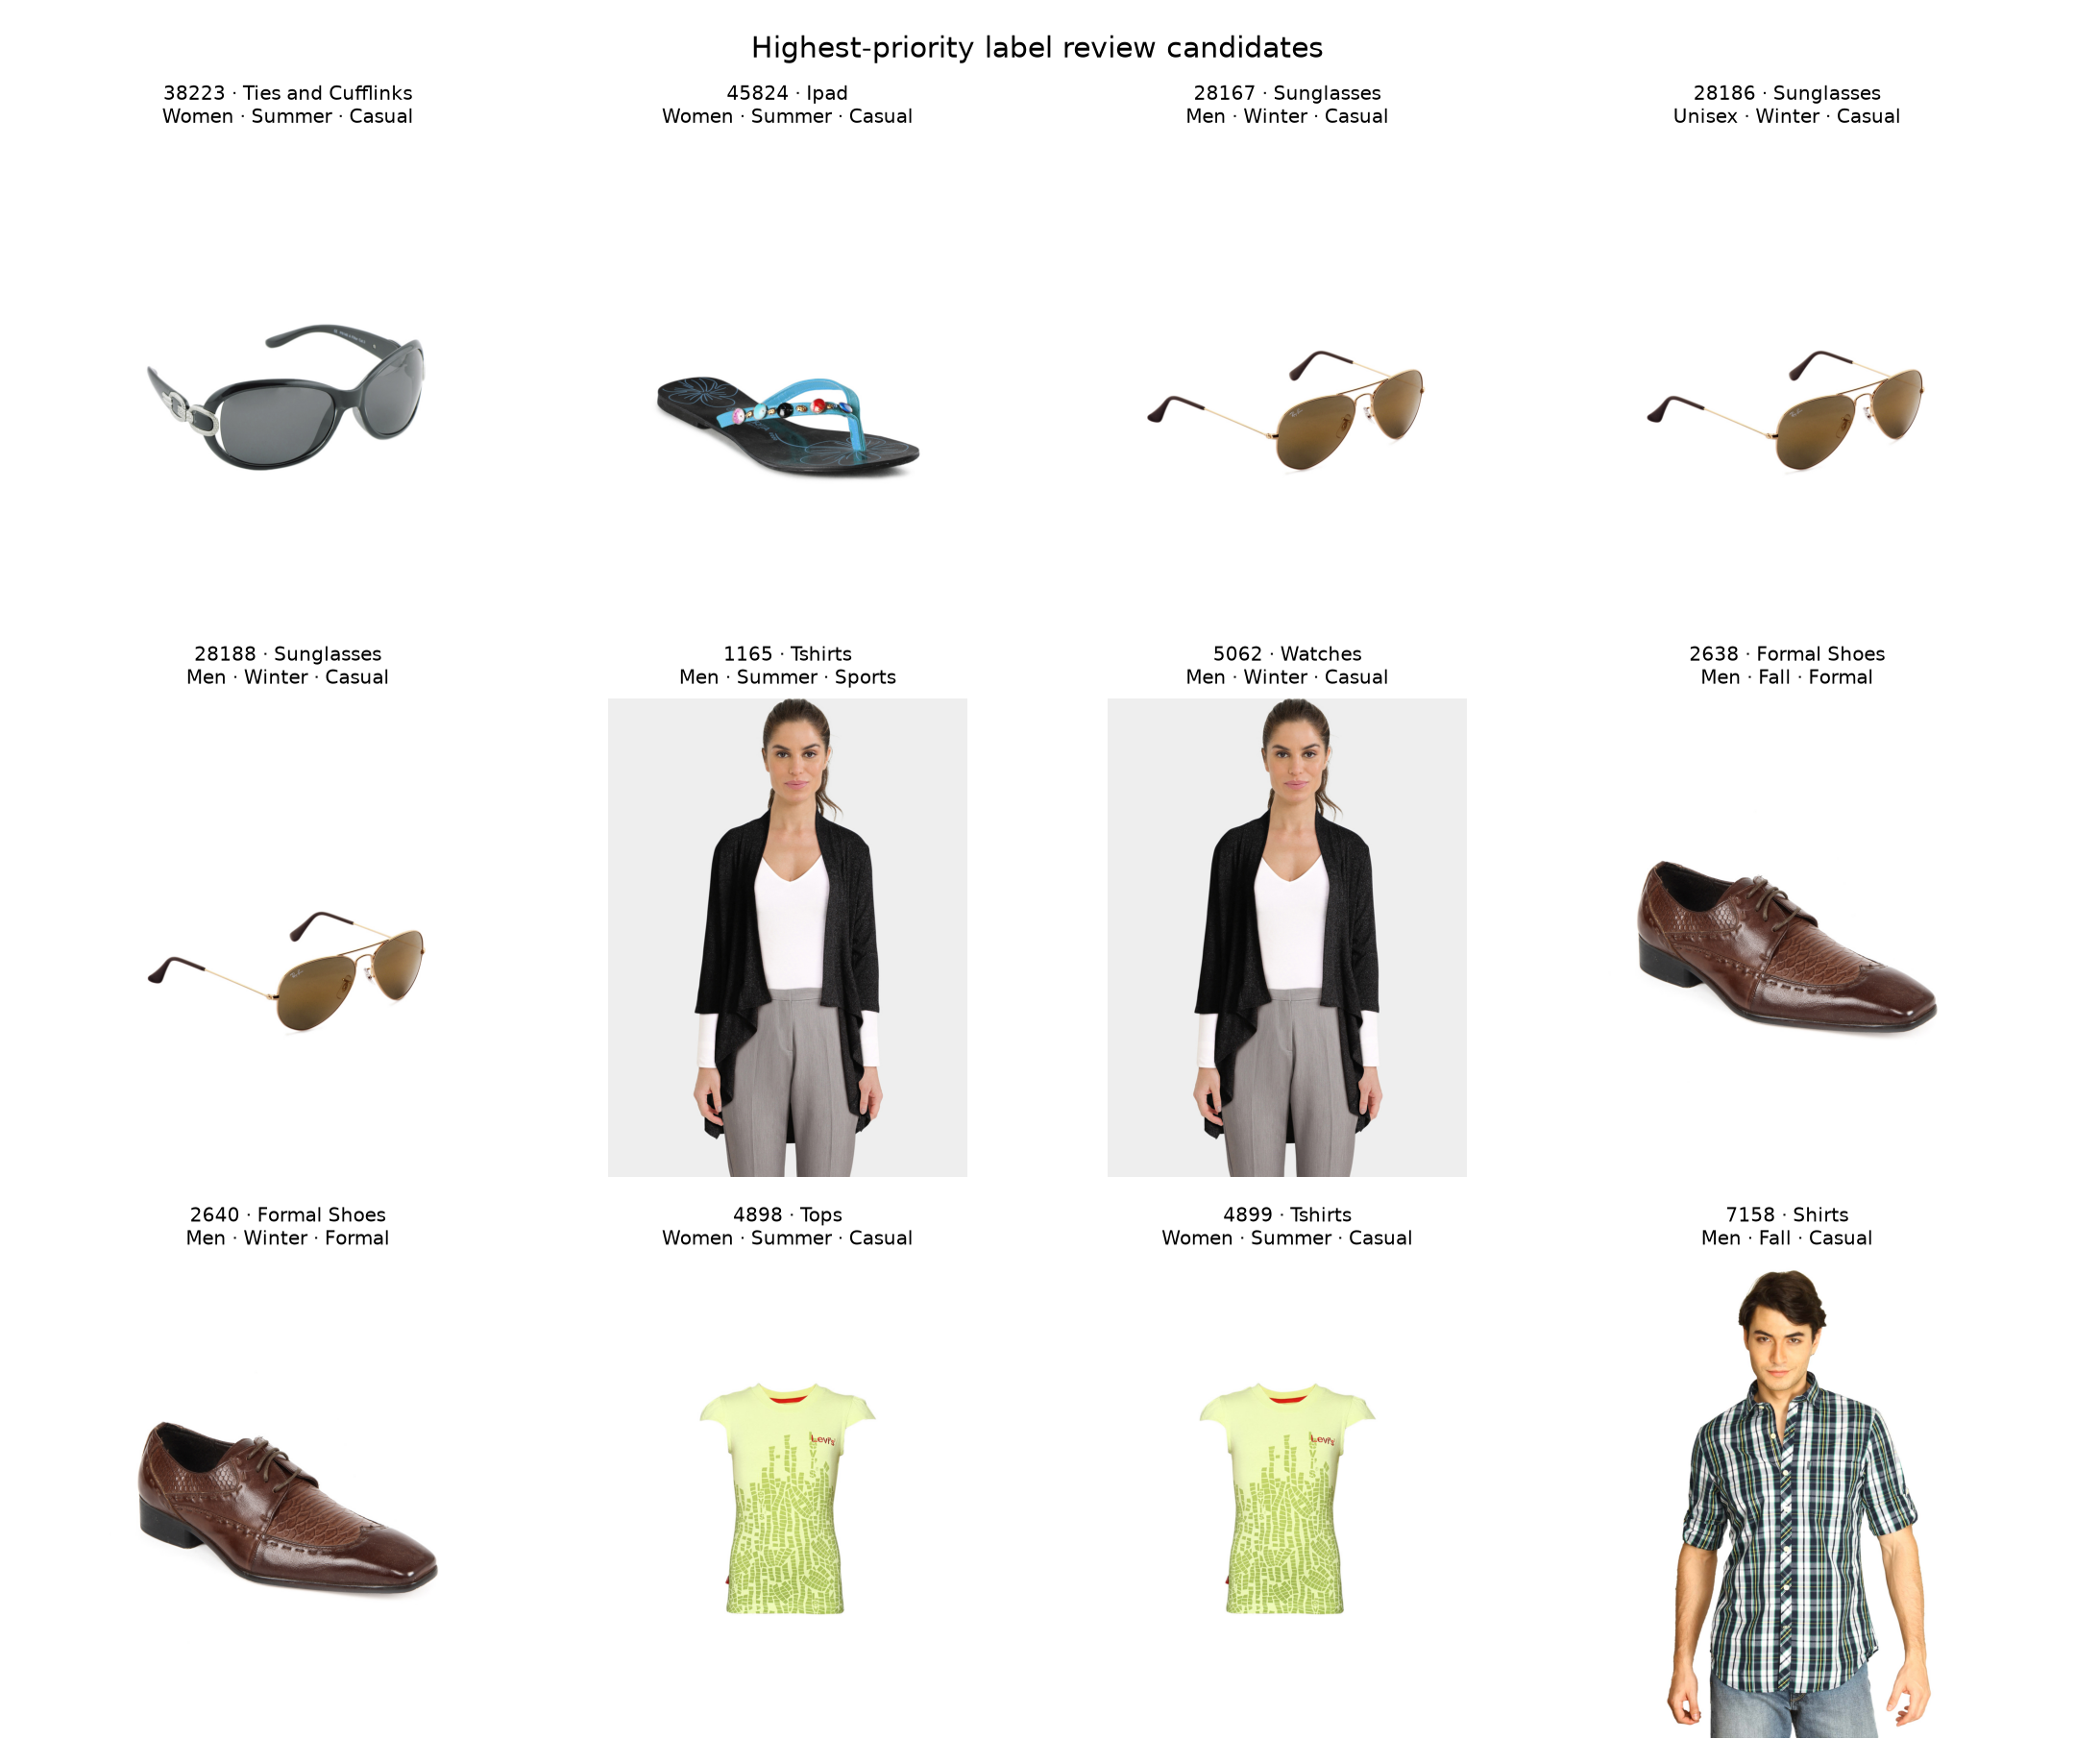

In [5]:
json_audit = summary["artifact_consistency"]["json"]
weirdness = pd.DataFrame([
    {"check": "CSV ↔ JSON label mismatches", "count": sum(json_audit["mismatch_counts"].values())},
    {"check": "Exact-image groups with target conflicts", "count": summary["images"]["exact_duplicates"]["label_conflict_groups"]},
    {"check": "Name ↔ gender review candidates", "count": summary["labels"]["name_gender_contradictions"]["count"]},
    {"check": "articleType hierarchy conflicts", "count": summary["labels"]["hierarchy_conflicts"]},
    {"check": "articleType singletons", "count": summary["labels"]["article_type_singletons"]},
    {"check": "articleType classes under 10 rows", "count": summary["labels"]["article_type_under_10"]},
])
display(weirdness)
display(pd.DataFrame(summary["labels"]["known_review_candidates"]))
display(pd.DataFrame(summary["labels"]["exact_duplicate_conflicts"]).head(10))
display(Image(filename=str(OUTPUT_DIR / "label-review-candidates.png")))

## 5. Image quality and duplicate risk

The teacher images are small delivery thumbnails. The original images retain much more detail. Same-ID perceptual checks test whether both files still depict the same product after resizing.

Exact hashes prove identical files. Perceptual hashes only create a review queue. The threshold sweep reports pair and component growth so a transitive chain is never presented as one confirmed duplicate product.

In [6]:
audits = summary["images"]["audits"]
quality = pd.DataFrame([
    {
        "source": source,
        "files": audit["files"],
        "median_megapixels": audit["megapixels_median"],
        "median_kib": audit["bytes_median"] / 1024,
        "header_errors": len(audit["header_errors"]),
        "decode_errors": len(audit["decode_errors"]),
        "decoded_files": audit["decoded_files"],
    }
    for source, audit in audits.items()
])
display(quality)
display(pd.Series(summary["images"]["same_id_comparison"], name="value").drop(labels=["examples", "errors", "teacher_dimensions"]).to_frame())
display(pd.Series(summary["images"]["exact_duplicates"], name="value").drop(labels=["conflict_examples", "largest_groups"]).to_frame())
display(pd.DataFrame(summary["images"]["near_duplicate_sample"]["sweep"]))

,source,files,median_megapixels,median_kib,header_errors,decode_errors,decoded_files
0,original,44441,1.5552,306.283203,0,0,512
1,teacher_train_present,38612,0.0048,13.506836,0,0,38612
2,teacher_test,5829,0.0048,16.189453,0,0,5829


,value
sample_size,512
median_pixel_ratio,324.0
median_psnr_db,43.463676
median_dhash_distance,0.0
share_dhash_at_most_6,1.0
median_file_size_ratio,25.78201


,value
groups,652
images,1431
largest_group,4
cross_split_groups,11
label_conflict_groups,22
conflict_counts_by_target,"{'gender': 8, 'articleType': 7, 'season': 9, '..."


,threshold,candidate_pairs,components,images_in_components,largest_component
0,0,38,15,39,5
1,2,275,60,196,22
2,4,1201,99,606,99
3,6,4251,80,1119,345


## 6. Decision ledger

There is no single winner for every purpose:

- **Labels:** tied on shared rows. The original CSV uses the same labels; JSON provides corroboration, not new annotation.
- **Images:** original wins on detail and current local coverage.
- **Fair assignment evaluation:** teacher split wins. The original exposes official test labels, so using all 44,446 rows would leak the answer key.
- **Recommended working set:** official teacher-train IDs joined to original high-resolution images and metadata. Keep all official test IDs quarantined.

In [7]:
decision_ledger = pd.DataFrame([
    {"question": "Are original labels cleaner?", "decision": "No evidence of cleaner labels", "evidence": "All shared fields match; JSON audit is reported above"},
    {"question": "Are original images better?", "decision": "Yes", "evidence": "Higher resolution, larger files, and same-ID perceptual agreement"},
    {"question": "Can all original rows be trained on?", "decision": "No", "evidence": "5,829 rows are the official hidden test population"},
    {"question": "What should preprocessing use?", "decision": "Teacher-train IDs + original images", "evidence": "Best image fidelity without test leakage"},
    {"question": "Should suspicious labels be auto-fixed?", "decision": "No", "evidence": "Review candidates need human confirmation"},
])
display(decision_ledger)
print(json.dumps(summary["decision"], indent=2))

,question,decision,evidence
0,Are original labels cleaner?,No evidence of cleaner labels,All shared fields match; JSON audit is reporte...
1,Are original images better?,Yes,"Higher resolution, larger files, and same-ID p..."
2,Can all original rows be trained on?,No,"5,829 rows are the official hidden test popula..."
3,What should preprocessing use?,Teacher-train IDs + original images,Best image fidelity without test leakage
4,Should suspicious labels be auto-fixed?,No,Review candidates need human confirmation


{
  "label_source": "Labels are identical for every shared teacher-train ID; the original JSON is a useful cross-check, not a cleaner independent annotation source.",
  "image_source": "Use original high-resolution images for official teacher-train IDs when the extra detail is useful; the restored teacher thumbnails are complete for every source-available train image but heavily downsampled.",
  "test_policy": "Keep all 5,829 teacher-test IDs and their recovered original labels out of training, tuning, feature selection, and model comparison."
}
